# Semantic Segmentation Test Metrics

This notebook reads semantic checkpoint-sweep outputs, computes summary metrics, and saves each plot as a PNG under a configurable output directory.


In [ ]:
# Notebook imports
# Generated from standard/third-party imports used throughout this notebook.
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import pandas as pd
import seaborn as sns
from concurrent.futures import as_completed, ProcessPoolExecutor
from pathlib import Path
from sklearn.metrics import accuracy_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, jaccard_score, precision_score, recall_score


## Config


In [1]:

# Checkpoint sweep output root. Expected structure:
# BASE_DIR/{graha_model,toy_model}/{last,epoch_000,...}/{sample_id}/*.npy
BASE_DIR = Path(
    "/explore/nobackup/people/ajkerr1/Lunar_FM/"
    "exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-"
    "norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/"
    "date_2026_07_21-time_17_59_42/"
)

# Checkpoint folder used for the static sample/global/per-chip plots.
CHECKPOINT_NAME = "epoch_099"

# Number of chips to visualize in the sample overlay section.
NUM_CHIPS = 30

# Configure plot/table outputs here.
OUTPUT_DIR = BASE_DIR
PLOT_OUTPUT_DIR = OUTPUT_DIR / "plots"
TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"
SAVE_PLOTS = True
PLOT_DPI = 200

# checkpoint_sweep/graha_model/epoch_099
GRAHA_DIR = BASE_DIR / "checkpoint_sweep/graha_model" / CHECKPOINT_NAME
DINO_DIR = BASE_DIR / "checkpoint_sweep/toy_model" / CHECKPOINT_NAME
GRAHA_EPOCH_ROOT = BASE_DIR / "checkpoint_sweep/graha_model"
DINO_EPOCH_ROOT = BASE_DIR / "checkpoint_sweep/toy_model"

COLOR_GT = "#FFC107"
COLOR_GRAHA = "#1E88E5"
COLOR_DINO = "#1AFF1A"
MODEL_PALETTE = {"Graha": COLOR_GRAHA, "DINOv3": "#004D40"}

PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}")
print(f"Checkpoint: {CHECKPOINT_NAME}")
print(f"Plot output: {PLOT_OUTPUT_DIR}")
print(f"Table output: {TABLE_OUTPUT_DIR}")

BASE_DIR: /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42
Checkpoint: epoch_099
Plot output: /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots
Table output: /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/tables


## Imports And Helpers


In [2]:

plt.rcParams.update(
    {
        "font.size": 16,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
    }
)

METRICS_TO_PLOT = [
    "Accuracy",
    "Precision",
    "Recall",
    "IoU",
    "Area Bias",
    "Specificity",
    "Average Precision",
]


def save_figure(fig, filename: str) -> Path:
    """Save a matplotlib figure if SAVE_PLOTS is enabled."""
    save_path = PLOT_OUTPUT_DIR / filename
    if SAVE_PLOTS:
        fig.savefig(save_path, dpi=PLOT_DPI, bbox_inches="tight")
        print(f"Saved plot to {save_path}")
    return save_path


def mask_2d(arr: np.ndarray) -> np.ndarray:
    """Return a 2D mask from possible singleton/channel-first arrays."""
    if arr.ndim == 3 and arr.shape[0] == 1:
        return arr[0]
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0]
    return arr


def display_band(image: np.ndarray, band: int = 0) -> np.ndarray:
    """Return one displayable image band from C,H,W input arrays."""
    if image.ndim == 3:
        return image[band]
    return image


def create_overlay(mask: np.ndarray, hex_color: str, alpha: float = 0.5) -> np.ndarray:
    """Convert a binary mask to an RGBA overlay."""
    rgb = mcolors.to_rgb(hex_color)
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[..., :3] = rgb
    overlay[..., 3] = (mask > 0).astype(np.float32) * alpha
    return overlay


def sample_dirs(model_dir: Path) -> list[Path]:
    return sorted([path for path in model_dir.iterdir() if path.is_dir()])


def load_sample_arrays(sample_id: str) -> dict[str, np.ndarray]:
    graha_sample_dir = GRAHA_DIR / sample_id
    dino_sample_dir = DINO_DIR / sample_id
    return {
        "input": np.load(graha_sample_dir / f"{sample_id}_input.npy"),
        "label": mask_2d(np.load(graha_sample_dir / f"{sample_id}_label.npy")),
        "graha_pred": mask_2d(np.load(graha_sample_dir / f"{sample_id}_pred.npy")),
        "dino_pred": mask_2d(np.load(dino_sample_dir / f"{sample_id}_pred.npy")),
    }


def binary_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Calculate the seven semantic metrics used by Metrics_LFM.ipynb."""
    y_true = np.asarray(y_true).astype(np.int64).reshape(-1)
    y_pred = np.asarray(y_pred).astype(np.int64).reshape(-1)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    area_bias = (tp + fp) / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    average_precision = average_precision_score(y_true, y_pred) if np.sum(y_true) > 0 else 0
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        "IoU": jaccard_score(y_true, y_pred, average="binary", zero_division=0),
        "Area Bias": area_bias,
        "Specificity": specificity,
        "Average Precision": average_precision,
    }


def metric_from_npy(metrics_path: Path, metric_name: str) -> float | None:
    """Read a named metric from a sweep metrics.npy file when available."""
    if not metrics_path.exists():
        return None
    data = np.load(metrics_path, allow_pickle=True)
    if getattr(data.dtype, "names", None) and metric_name in data.dtype.names:
        return float(data[metric_name])
    if data.ndim == 0:
        item = data.item()
        if isinstance(item, dict) and metric_name in item:
            return float(item[metric_name])
    return None

## Select Sample


In [3]:
patch_dirs = [path.name for path in sample_dirs(GRAHA_DIR)]
if not patch_dirs:
    raise FileNotFoundError(f"No sample directories found in {GRAHA_DIR}")

# Change this manually if you want a specific sample.
SAMPLE_CHIP = patch_dirs[0]

print(f"Found {len(patch_dirs)} samples in {GRAHA_DIR}")
print(f"Selected sample: {SAMPLE_CHIP}")
print(f"Will visualize first {min(NUM_CHIPS, len(patch_dirs))} chips.")

Found 100 samples in /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/checkpoint_sweep/graha_model/epoch_099
Selected sample: M1098029461CE_r2850_c450
Will visualize first 30 chips.


## Plot Sample Overlays


Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1098029461CE_r2850_c450.png


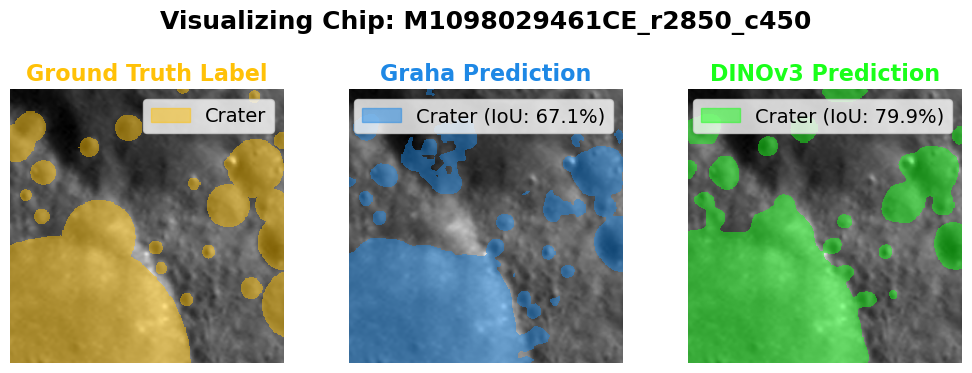

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1098050897CE_r8550_c1050.png


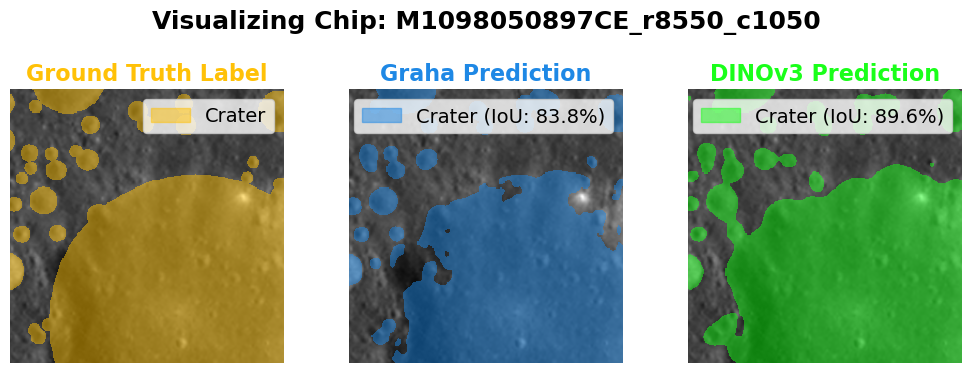

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1098058035CE_r600_c450.png


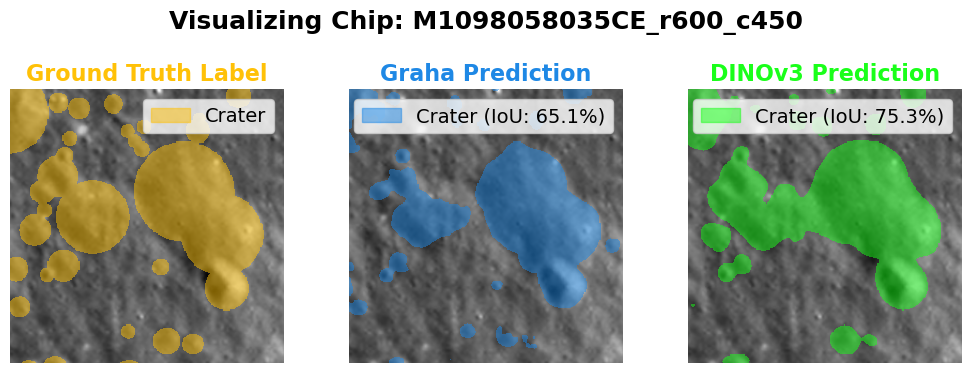

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1107459759CE_r3900_c600.png


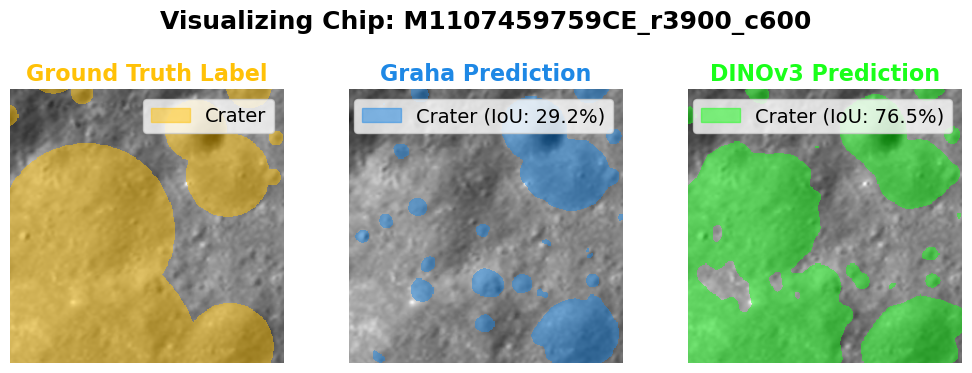

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1107481196CE_r1800_c450.png


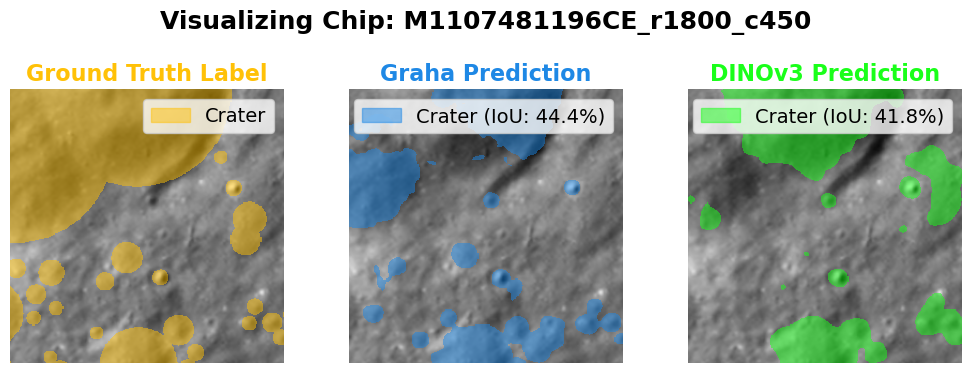

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1107481196CE_r6000_c150.png


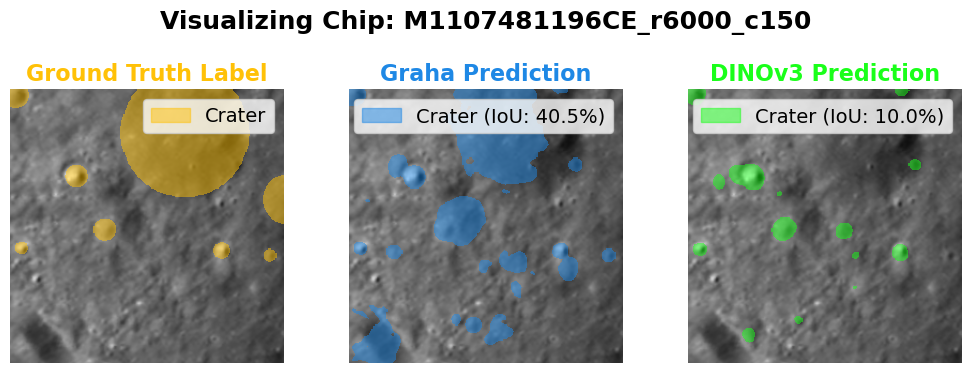

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1113382413CE_r1350_c150.png


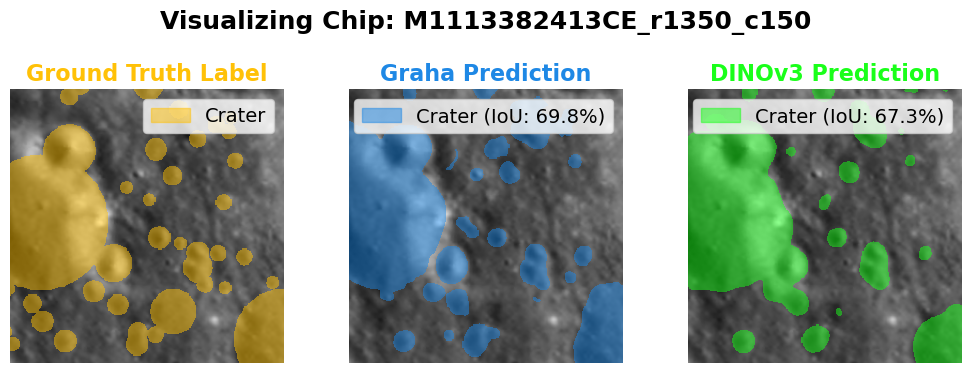

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1123653920CE_r7350_c450.png


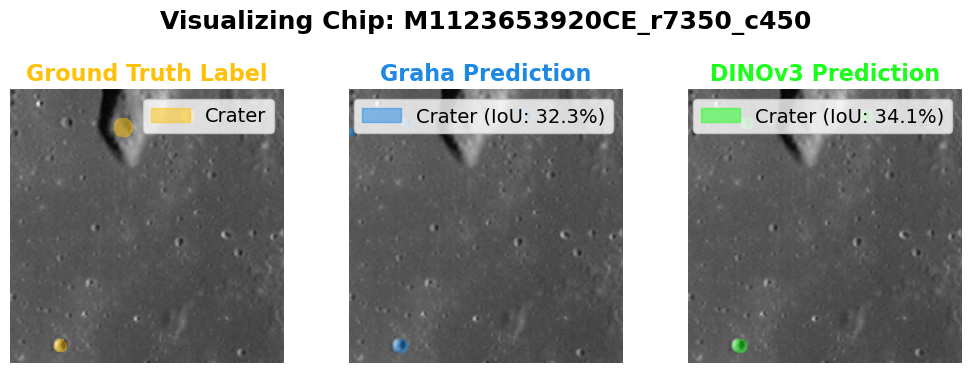

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1123661040CE_r10200_c750.png


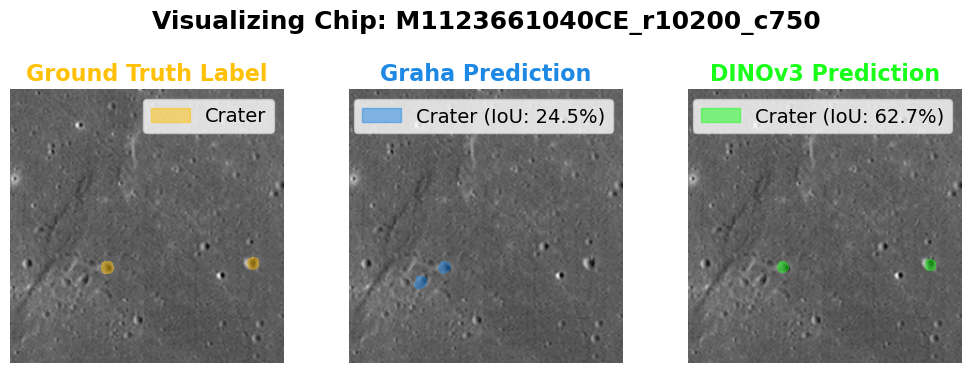

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1123661040CE_r10800_c750.png


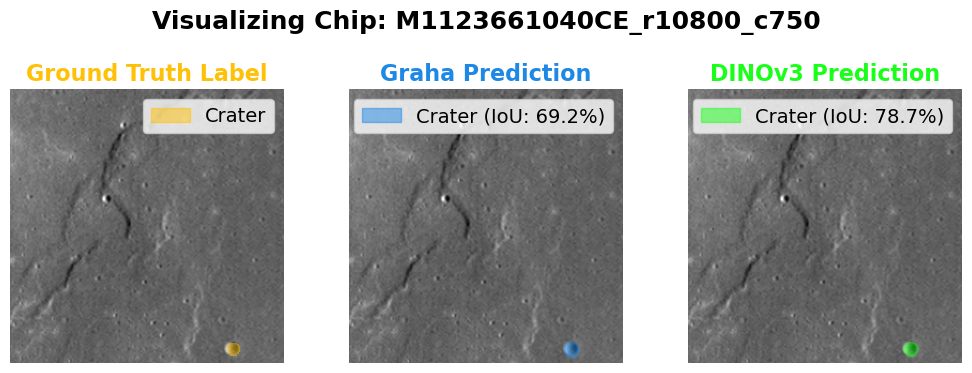

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1123668134CE_r5550_c450.png


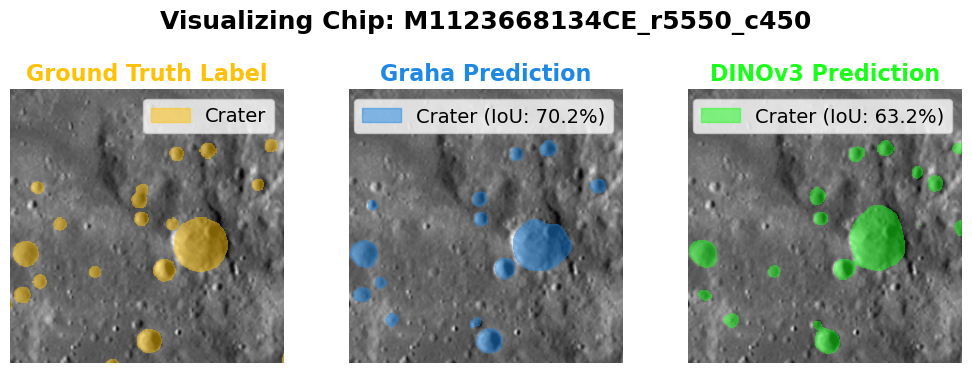

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1127518784CE_r9450_c1650.png


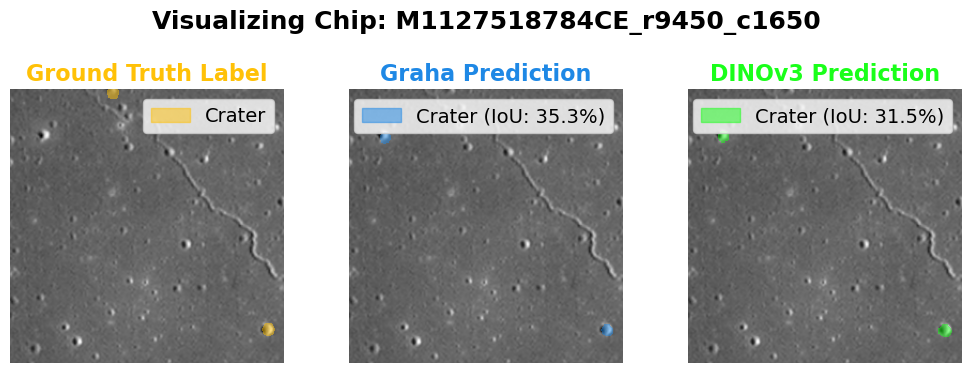

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1139292562CE_r1200_c1050.png


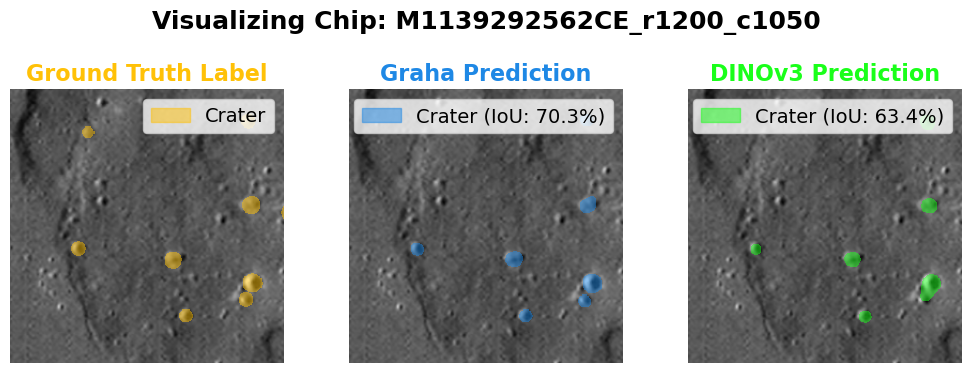

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1139306795CE_r9300_c1650.png


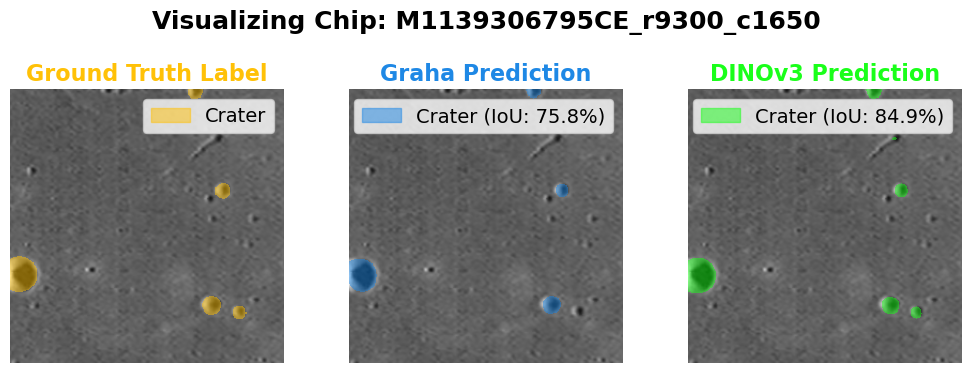

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1142815832CE_r1800_c750.png


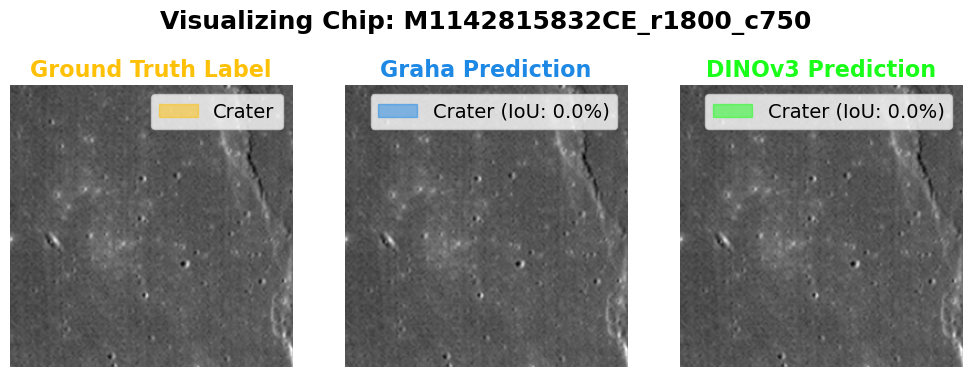

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1142816653CE_r10950_c750.png


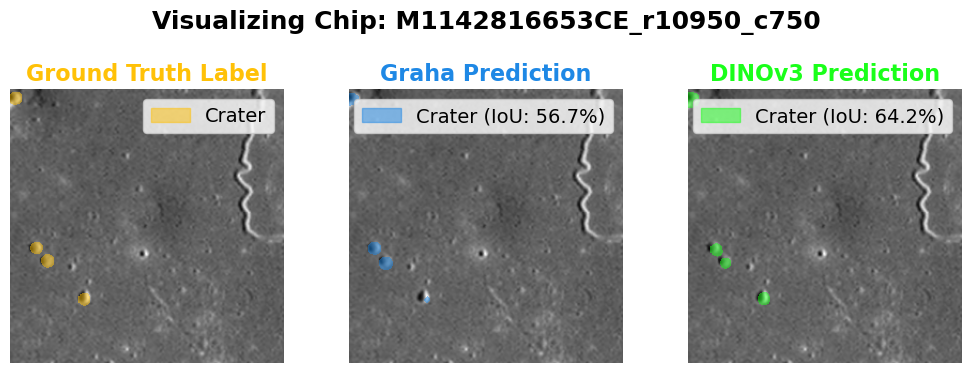

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1144011195CE_r1650_c300.png


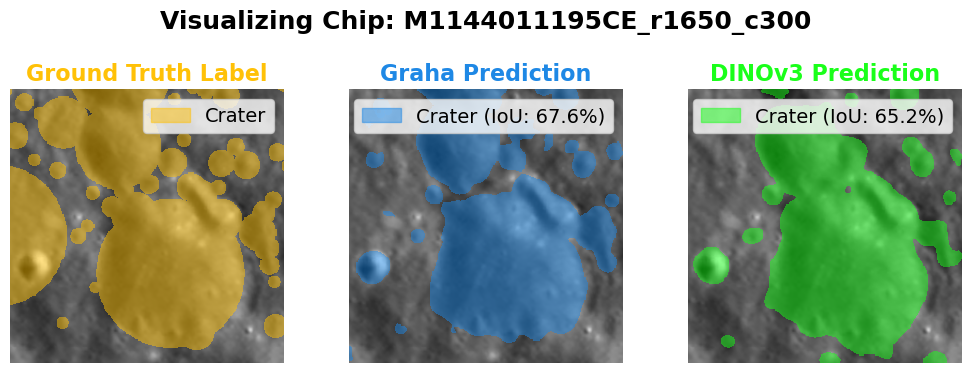

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1144011195CE_r3450_c300.png


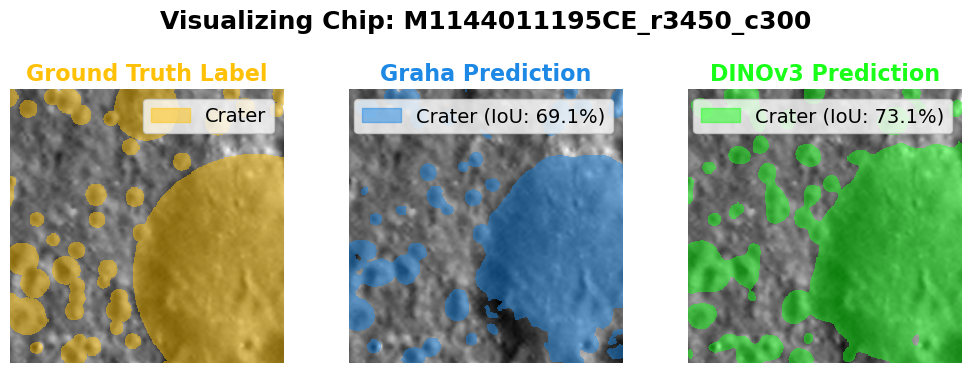

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1144011195CE_r3450_c600.png


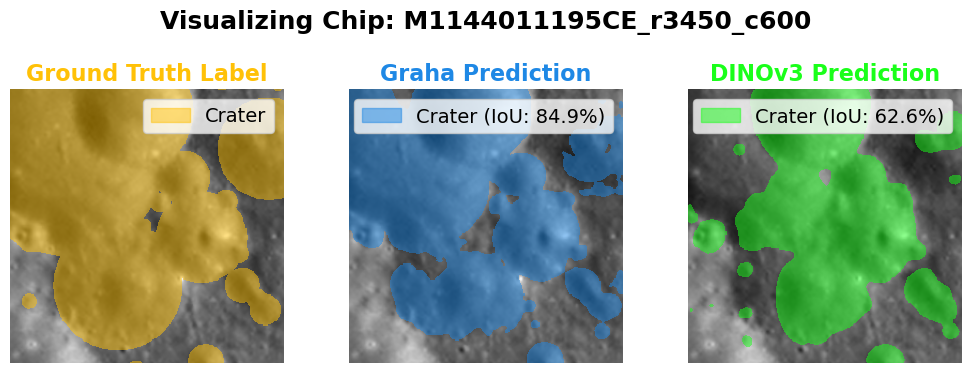

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1154285484CE_r8850_c750.png


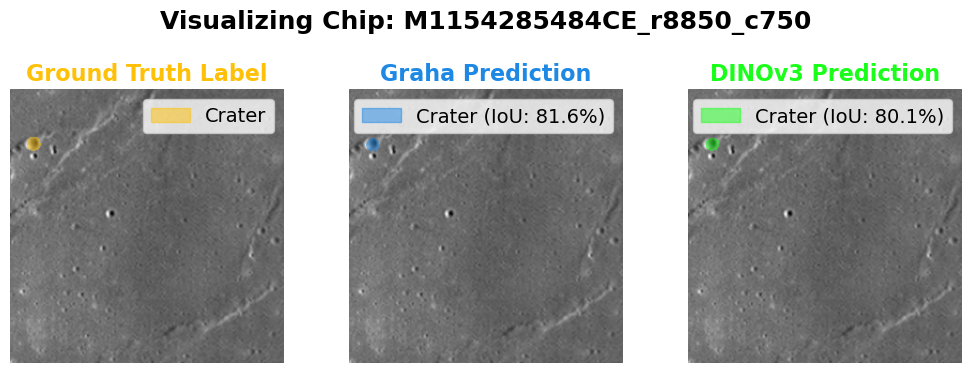

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1154292583CE_r4350_c750.png


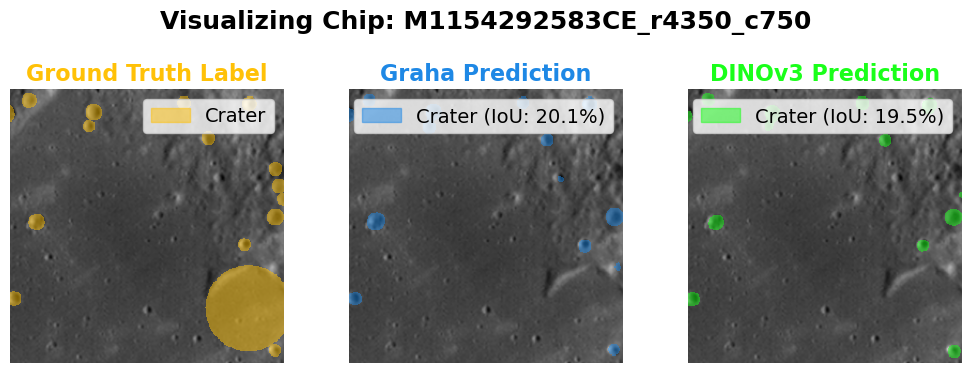

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1157820047CE_r13050_c1650.png


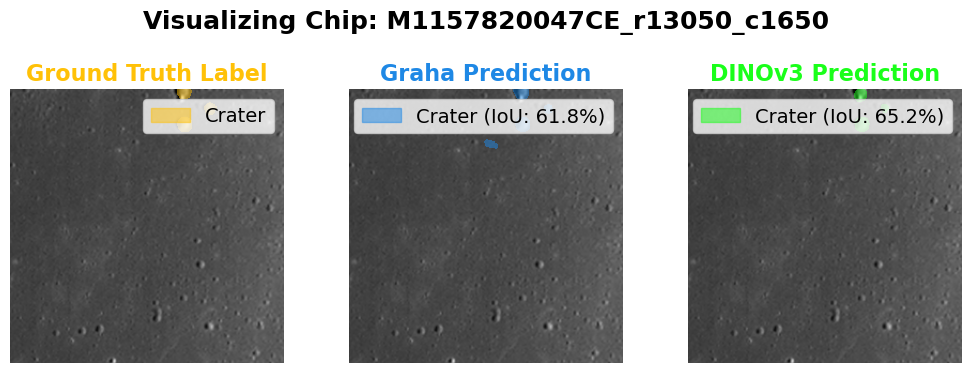

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1158126119CE_r3600_c600.png


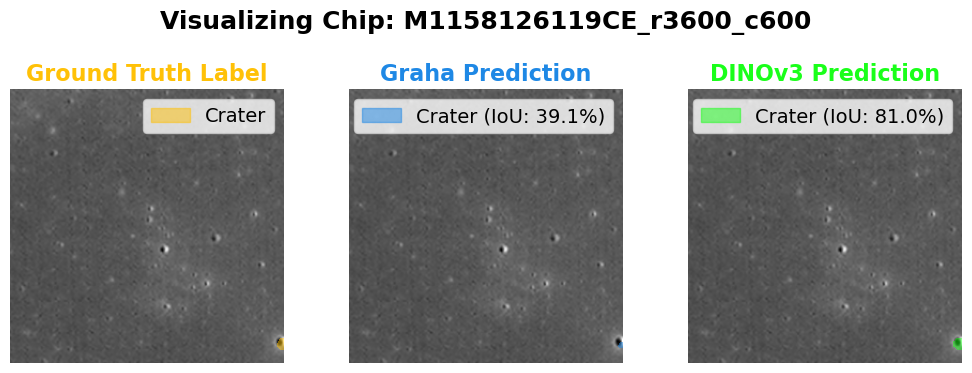

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1159300679CE_r2400_c600.png


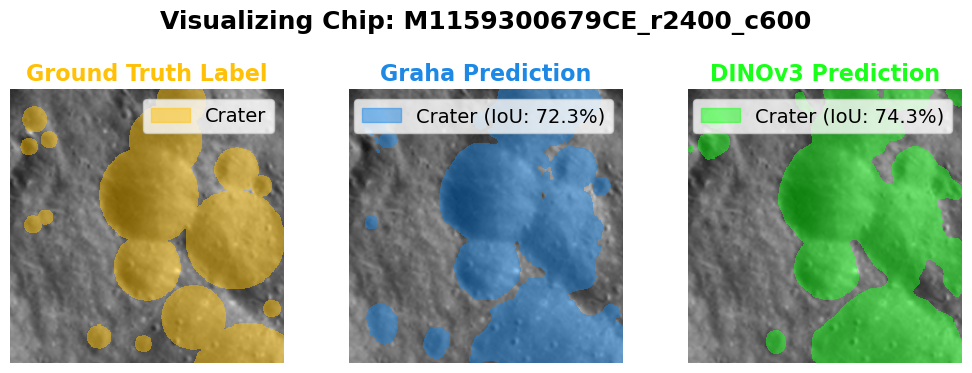

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1159314942CE_r8100_c900.png


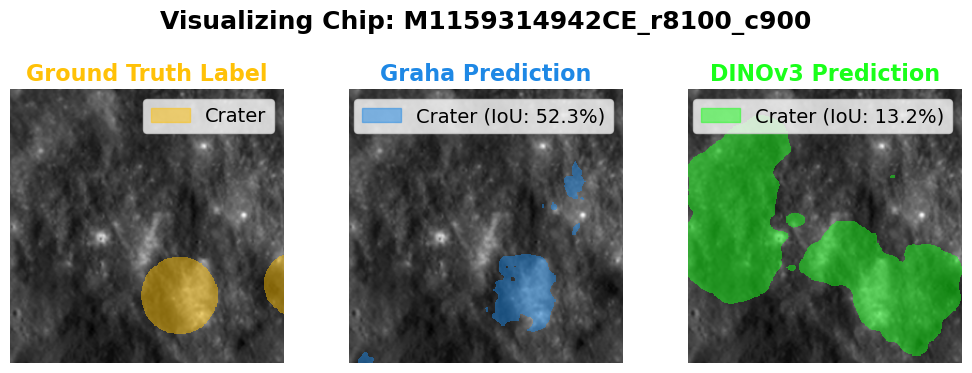

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1169898969CE_r2700_c900.png


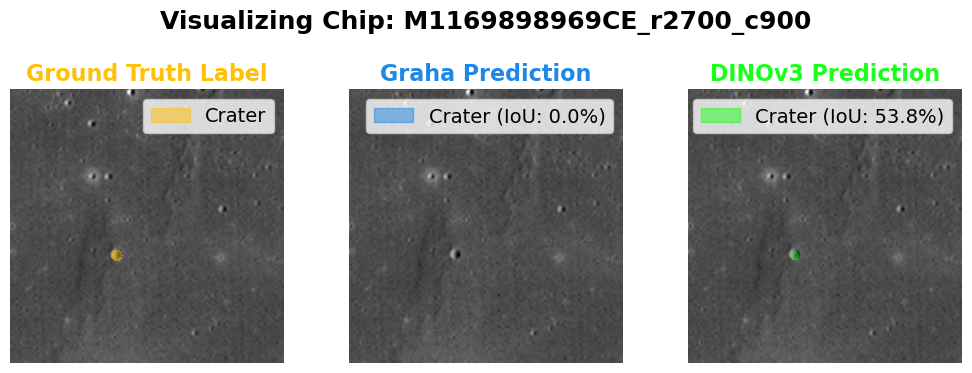

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1174607884CE_r1050_c150.png


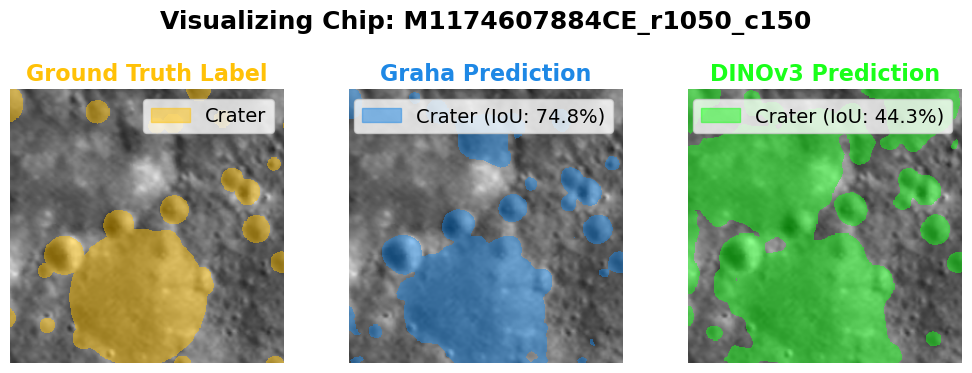

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1184013881CE_r3300_c300.png


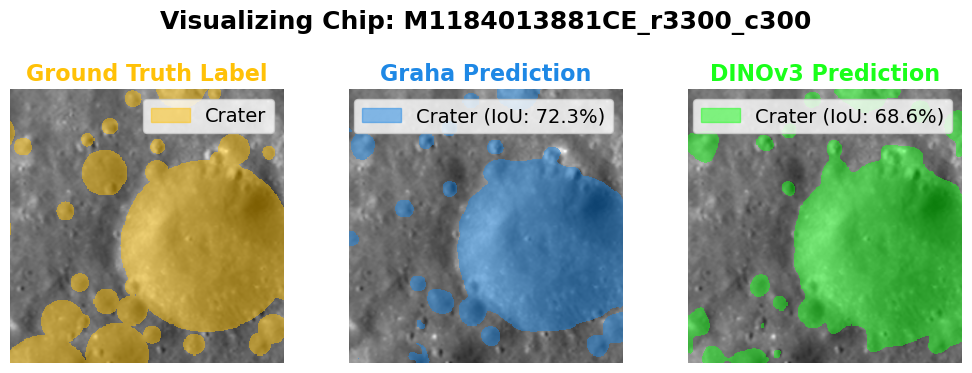

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1184554532CE_r3750_c2100.png


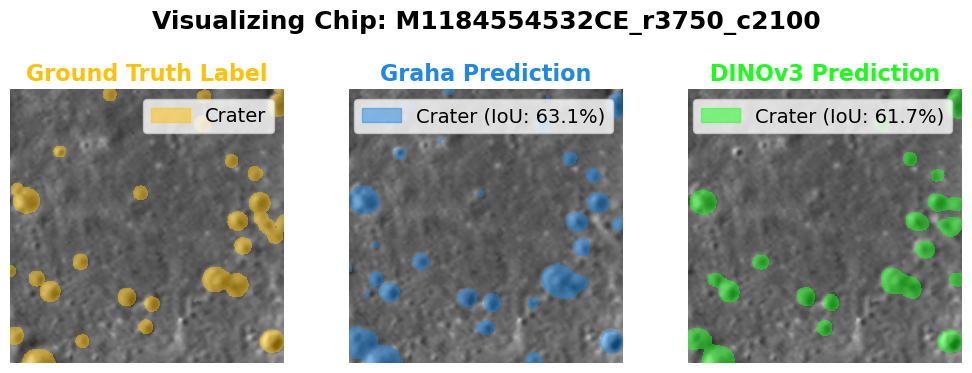

Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/sample_overlay_M1184894506CE_r11850_c450.png


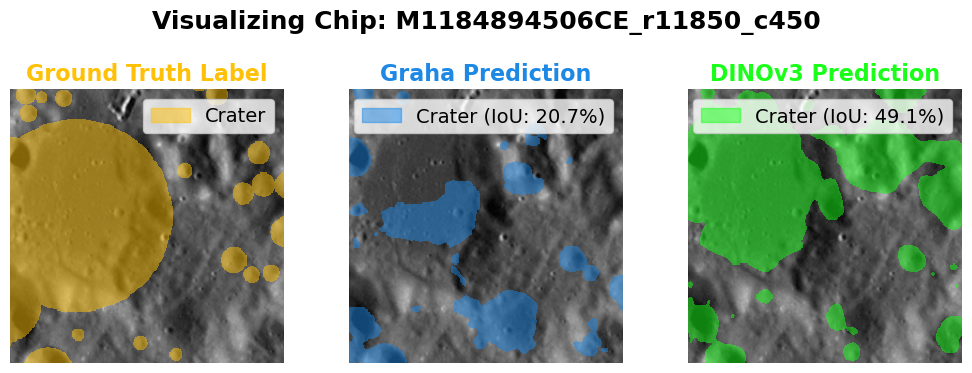

In [4]:
def plot_sample_overlay(sample_chip: str) -> None:
    arrays = load_sample_arrays(sample_chip)
    img_to_plot = display_band(arrays["input"], band=0)

    graha_metrics = binary_metrics(arrays["label"], arrays["graha_pred"])
    dino_metrics = binary_metrics(arrays["label"], arrays["dino_pred"])
    graha_iou = metric_from_npy(GRAHA_DIR / sample_chip / "metrics.npy", "iou")
    dino_iou = metric_from_npy(DINO_DIR / sample_chip / "metrics.npy", "iou")
    if graha_iou is None:
        graha_iou = graha_metrics["IoU"]
    if dino_iou is None:
        dino_iou = dino_metrics["IoU"]

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle(f"Visualizing Chip: {sample_chip}", fontsize=18, fontweight="bold")

    axes[0].imshow(img_to_plot, cmap="gray")
    axes[0].imshow(create_overlay(arrays["label"], COLOR_GT, alpha=0.5), interpolation="none")
    axes[0].set_title("Ground Truth Label", color=COLOR_GT, fontweight="bold")
    axes[0].axis("off")
    axes[0].legend(handles=[mpatches.Patch(color=COLOR_GT, alpha=0.5, label="Crater")], loc="upper right")

    axes[1].imshow(img_to_plot, cmap="gray")
    axes[1].imshow(create_overlay(arrays["graha_pred"], COLOR_GRAHA, alpha=0.5), interpolation="none")
    axes[1].set_title("Graha Prediction", color=COLOR_GRAHA, fontweight="bold")
    axes[1].axis("off")
    axes[1].legend(
        handles=[mpatches.Patch(color=COLOR_GRAHA, alpha=0.5, label=f"Crater (IoU: {graha_iou * 100:.1f}%)")],
        loc="upper right",
    )

    axes[2].imshow(img_to_plot, cmap="gray")
    axes[2].imshow(create_overlay(arrays["dino_pred"], COLOR_DINO, alpha=0.5), interpolation="none")
    axes[2].set_title("DINOv3 Prediction", color=COLOR_DINO, fontweight="bold")
    axes[2].axis("off")
    axes[2].legend(
        handles=[mpatches.Patch(color=COLOR_DINO, alpha=0.5, label=f"Crater (IoU: {dino_iou * 100:.1f}%)")],
        loc="upper right",
    )

    plt.tight_layout()
    save_figure(fig, f"sample_overlay_{sample_chip}.png")
    plt.show()


for sample_chip in patch_dirs[:NUM_CHIPS]:
    plot_sample_overlay(sample_chip)

## Inspect Sample Metrics Files


In [5]:
def inspect_metrics(model_name: str, chip_dir: Path) -> None:
    print(f"=== {model_name} Metrics for {SAMPLE_CHIP} ===")
    txt_path = chip_dir / "metrics.txt"
    npy_path = chip_dir / "metrics.npy"

    if txt_path.exists():
        print("--- metrics.txt ---")
        print(txt_path.read_text().strip())
    else:
        print("metrics.txt not found.")

    print()
    if npy_path.exists():
        print("--- metrics.npy ---")
        data = np.load(npy_path, allow_pickle=True)
        print(data.item() if data.ndim == 0 else data)
    else:
        print("metrics.npy not found.")
    print("\n" + "=" * 50 + "\n")

inspect_metrics("Graha", GRAHA_DIR / SAMPLE_CHIP)
inspect_metrics("DINOv3", DINO_DIR / SAMPLE_CHIP)


=== Graha Metrics for M1098029461CE_r2850_c450 ===
--- metrics.txt ---
model: Graha
checkpoint: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/checkpoints/full_model/model-epoch-99-val-loss=0.207.ckpt
sample_key: M1098029461CE_r2850_c450
pixel_accuracy: 0.83543396
foreground_precision: 0.84664439
foreground_recall: 0.76439373
foreground_f1: 0.80341942
iou: 0.67142944
average_precision: 0.85576987
background_average_precision: 0.87079609
mean_average_precision: 0.86328298
predicted_foreground_fraction: 0.39720154
ground_truth_foreground_fraction: 0.43994141

--- metrics.npy ---
(0.83543395996081, 0.846644385539992, 0.764393729189524, 0.8034194215843821, 0.6714294418715966, 0.8557698734917376, 0.8707960936976796, 0.8632829835947087, 0.3972015380858769, 0.4399414062499329)


=== DINOv3 Metrics for M1098029461CE_r2850_c450 ===
--- metr

## Calculate Per-Chip Metrics For Selected Checkpoint


In [6]:
metrics_data = []
label_arrays = []
graha_pred_arrays = []
dino_pred_arrays = []

print(f"Processing {len(patch_dirs)} chips from checkpoint '{CHECKPOINT_NAME}' to calculate seven metrics...")

for chip in patch_dirs:
    label_path = GRAHA_DIR / chip / f"{chip}_label.npy"
    graha_pred_path = GRAHA_DIR / chip / f"{chip}_pred.npy"
    dino_pred_path = DINO_DIR / chip / f"{chip}_pred.npy"

    if not (label_path.exists() and graha_pred_path.exists() and dino_pred_path.exists()):
        continue

    label = mask_2d(np.load(label_path)).reshape(-1)
    graha_pred = mask_2d(np.load(graha_pred_path)).reshape(-1)
    dino_pred = mask_2d(np.load(dino_pred_path)).reshape(-1)

    label_arrays.append(label)
    graha_pred_arrays.append(graha_pred)
    dino_pred_arrays.append(dino_pred)

    metrics_data.append({"Model": "Graha", "Chip": chip, **binary_metrics(label, graha_pred)})
    metrics_data.append({"Model": "DINOv3", "Chip": chip, **binary_metrics(label, dino_pred)})

if not label_arrays:
    raise RuntimeError("No matched label/prediction arrays were found for the selected checkpoint.")

df_metrics = pd.DataFrame(metrics_data)
all_labels = np.concatenate(label_arrays)
all_graha_preds = np.concatenate(graha_pred_arrays)
all_dino_preds = np.concatenate(dino_pred_arrays)

per_chip_csv = TABLE_OUTPUT_DIR / f"per_chip_metrics_{CHECKPOINT_NAME}.csv"
df_metrics.to_csv(per_chip_csv, index=False)

print(f"Processed {len(df_metrics) // 2} matched chips.")
print(f"Saved per-chip metrics to {per_chip_csv}")
df_metrics.head()

Processing 100 chips from checkpoint 'epoch_099' to calculate seven metrics...
Processed 100 matched chips.
Saved per-chip metrics to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/tables/per_chip_metrics_epoch_099.csv


,Model,Chip,Accuracy,Precision,Recall,IoU,Area Bias,Specificity,Average Precision
0,Graha,M1098029461CE_r2850_c450,0.835434,0.846644,0.764394,0.671429,0.902851,0.891238,0.750823
1,DINOv3,M1098029461CE_r2850_c450,0.902435,0.893401,0.883671,0.799385,0.989109,0.917175,0.840650
2,Graha,M1098050897CE_r8550_c1050,0.896011,0.962104,0.866963,0.838335,0.901111,0.943810,0.916857
3,DINOv3,M1098050897CE_r8550_c1050,0.930450,0.929386,0.961215,0.895793,1.034247,0.879829,0.917464
4,Graha,M1098058035CE_r600_c450,0.864090,0.930810,0.683900,0.650815,0.734737,0.970094,0.753662


## Global Metrics


In [7]:
global_rows = []
for model_name, preds in [("Graha", all_graha_preds), ("DINOv3", all_dino_preds)]:
    global_rows.append({"Model": model_name, **binary_metrics(all_labels, preds)})

df_global_metrics = pd.DataFrame(global_rows)
global_csv = TABLE_OUTPUT_DIR / f"global_metrics_{CHECKPOINT_NAME}.csv"
df_global_metrics.to_csv(global_csv, index=False)

print("=" * 140)
print("OVERALL GLOBAL METRICS (All Pixels)")
print("=" * 140)
for row in global_rows:
    print(
        f"{row['Model']:<6} -> Accuracy ((TP+TN)/Total): {row['Accuracy']:.4f} | "
        f"Precision (TP/(TP+FP)): {row['Precision']:.4f} | "
        f"Recall (TP/(TP+FN)): {row['Recall']:.4f}"
    )
    print(
        f"          IoU (TP/(TP+FP+FN)): {row['IoU']:.4f} | "
        f"Area Bias ((TP+FP)/(TP+FN)): {row['Area Bias']:.4f} | "
        f"Specificity (TN/(TN+FP)): {row['Specificity']:.4f} | "
        f"AP (Area under PR Curve): {row['Average Precision']:.4f}"
    )
    print("-" * 140)
print(f"Saved global metrics to {global_csv}")
df_global_metrics

OVERALL GLOBAL METRICS (All Pixels)
Graha  -> Accuracy ((TP+TN)/Total): 0.8988 | Precision (TP/(TP+FP)): 0.7983 | Recall (TP/(TP+FN)): 0.6798
          IoU (TP/(TP+FP+FN)): 0.5802 | Area Bias ((TP+FP)/(TP+FN)): 0.8515 | Specificity (TN/(TN+FP)): 0.9555 | AP (Area under PR Curve): 0.6086
--------------------------------------------------------------------------------------------------------------------------------------------
DINOv3 -> Accuracy ((TP+TN)/Total): 0.8991 | Precision (TP/(TP+FP)): 0.7691 | Recall (TP/(TP+FN)): 0.7283
          IoU (TP/(TP+FP+FN)): 0.5976 | Area Bias ((TP+FP)/(TP+FN)): 0.9469 | Specificity (TN/(TN+FP)): 0.9434 | AP (Area under PR Curve): 0.6160
--------------------------------------------------------------------------------------------------------------------------------------------
Saved global metrics to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epoch

,Model,Accuracy,Precision,Recall,IoU,Area Bias,Specificity,Average Precision
0,Graha,0.898798,0.798350,0.679796,0.580177,0.851502,0.955524,0.608592
1,DINOv3,0.899103,0.769061,0.728262,0.597579,0.946949,0.943355,0.615984


## Plot Confusion Matrices


Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/confusion_matrices_epoch_099.png


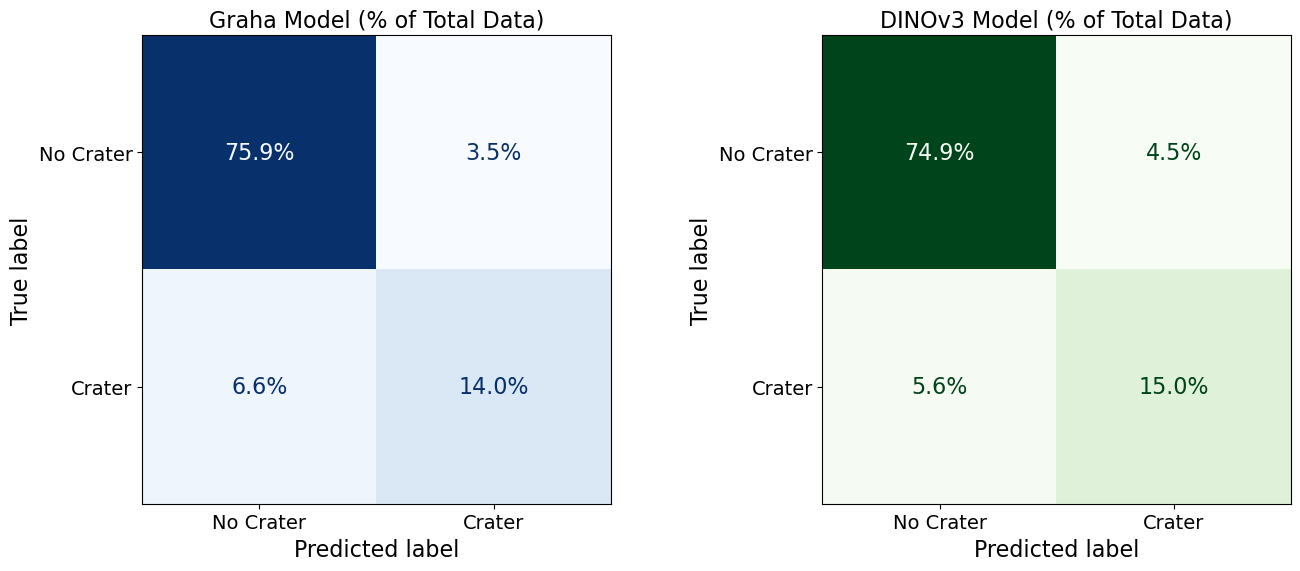

In [8]:
class_names = ["No Crater", "Crater"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_graha = confusion_matrix(all_labels, all_graha_preds, normalize="all")
ConfusionMatrixDisplay(cm_graha, display_labels=class_names).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=".1%"
)
axes[0].set_title("Graha Model (% of Total Data)")

cm_dino = confusion_matrix(all_labels, all_dino_preds, normalize="all")
ConfusionMatrixDisplay(cm_dino, display_labels=class_names).plot(
    ax=axes[1], cmap="Greens", colorbar=False, values_format=".1%"
)
axes[1].set_title("DINOv3 Model (% of Total Data)")

plt.tight_layout()
save_figure(fig, f"confusion_matrices_{CHECKPOINT_NAME}.png")
plt.show()


## Plot Per-Chip Metric Distributions


Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/per_chip_metric_distributions_epoch_099.png


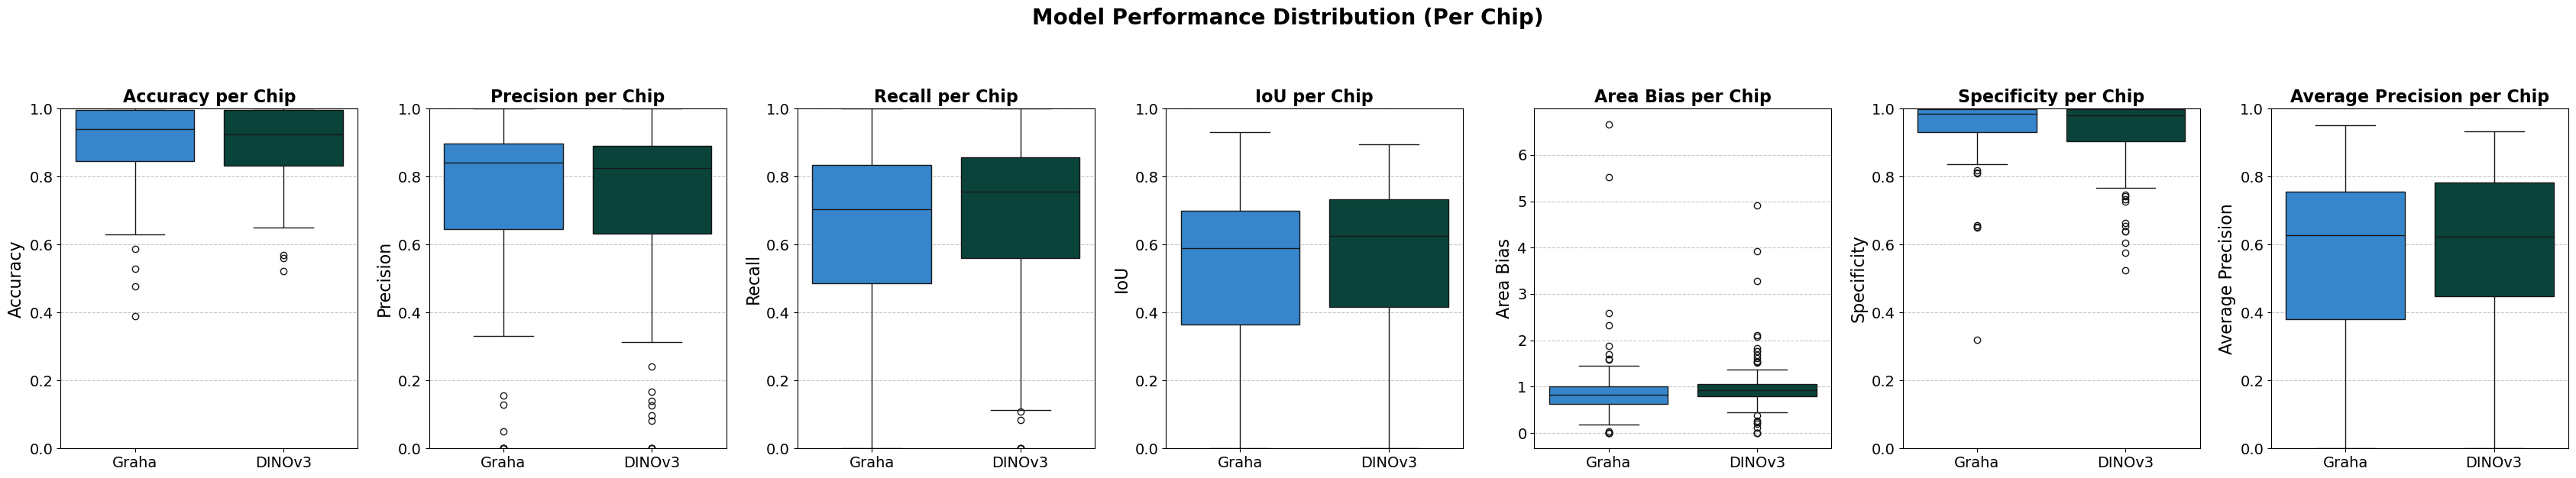

In [9]:
fig, axes = plt.subplots(1, 7, figsize=(34, 6))
axes = axes.flatten()

for i, metric in enumerate(METRICS_TO_PLOT):
    sns.boxplot(
        data=df_metrics,
        x="Model",
        y=metric,
        hue="Model",
        legend=False,
        ax=axes[i],
        palette=MODEL_PALETTE,
    )
    axes[i].set_title(f"{metric} per Chip", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)
    if metric != "Area Bias":
        axes[i].set_ylim(0, 1)
    axes[i].yaxis.grid(True, linestyle="--", alpha=0.7)

plt.suptitle("Model Performance Distribution (Per Chip)", fontsize=20, fontweight="bold", y=1.05)
plt.tight_layout()
save_figure(fig, f"per_chip_metric_distributions_{CHECKPOINT_NAME}.png")
plt.show()

## Calculate Metrics Across Epochs


In [10]:

N_PROCESS_WORKERS = 10

def calculate_epoch_metrics(epoch: str) -> dict:
    epoch_num = int(epoch.split("_")[1])
    graha_epoch_dir = GRAHA_EPOCH_ROOT / epoch
    dino_epoch_dir = DINO_EPOCH_ROOT / epoch
    chips = [path.name for path in sample_dirs(graha_epoch_dir)]

    graha_labels, graha_preds = [], []
    dino_labels, dino_preds = [], []

    for chip in chips:
        g_label_path = graha_epoch_dir / chip / f"{chip}_label.npy"
        g_pred_path = graha_epoch_dir / chip / f"{chip}_pred.npy"
        d_label_path = dino_epoch_dir / chip / f"{chip}_label.npy"
        d_pred_path = dino_epoch_dir / chip / f"{chip}_pred.npy"

        if g_label_path.exists() and g_pred_path.exists():
            graha_labels.append(mask_2d(np.load(g_label_path)).reshape(-1))
            graha_preds.append(mask_2d(np.load(g_pred_path)).reshape(-1))

        if d_label_path.exists() and d_pred_path.exists():
            dino_labels.append(mask_2d(np.load(d_label_path)).reshape(-1))
            dino_preds.append(mask_2d(np.load(d_pred_path)).reshape(-1))

    graha_metrics = None
    if graha_labels:
        graha_metrics = binary_metrics(np.concatenate(graha_labels), np.concatenate(graha_preds))

    dino_metrics = None
    if dino_labels:
        dino_metrics = binary_metrics(np.concatenate(dino_labels), np.concatenate(dino_preds))

    return {
        "epoch": epoch,
        "epoch_num": epoch_num,
        "graha_metrics": graha_metrics,
        "dino_metrics": dino_metrics,
    }


epoch_folders = sorted([path.name for path in GRAHA_EPOCH_ROOT.iterdir() if path.is_dir() and path.name.startswith("epoch_")])
print(f"Starting metric calculations across {len(epoch_folders)} epochs with {N_PROCESS_WORKERS} process workers...")

graha_history = {"Epoch": [], **{metric: [] for metric in METRICS_TO_PLOT}}
dino_history = {"Epoch": [], **{metric: [] for metric in METRICS_TO_PLOT}}
results = []

mp_context = mp.get_context("fork") if hasattr(mp, "get_context") else None
executor_kwargs = {"max_workers": N_PROCESS_WORKERS}
if mp_context is not None:
    executor_kwargs["mp_context"] = mp_context

with ProcessPoolExecutor(**executor_kwargs) as executor:
    futures = {executor.submit(calculate_epoch_metrics, epoch): epoch for epoch in epoch_folders}
    for future in as_completed(futures):
        result = future.result()
        results.append(result)
        if result["epoch_num"] % 10 == 0:
            print(f"Processed through {result['epoch']}...")

for result in sorted(results, key=lambda item: item["epoch_num"]):
    if result["graha_metrics"] is not None:
        graha_history["Epoch"].append(result["epoch_num"])
        for metric_name, value in result["graha_metrics"].items():
            graha_history[metric_name].append(value)

    if result["dino_metrics"] is not None:
        dino_history["Epoch"].append(result["epoch_num"])
        for metric_name, value in result["dino_metrics"].items():
            dino_history[metric_name].append(value)

df_graha = pd.DataFrame(graha_history)
df_dino = pd.DataFrame(dino_history)
print("Epoch metric calculations complete.")
print(f"Graha epochs: {len(df_graha)} | DINOv3 epochs: {len(df_dino)}")

Starting metric calculations across 100 epochs with 10 process workers...
Processed through epoch_000...
Processed through epoch_010...
Processed through epoch_020...
Processed through epoch_030...
Processed through epoch_040...
Processed through epoch_050...
Processed through epoch_060...
Processed through epoch_070...
Processed through epoch_080...
Processed through epoch_090...
Epoch metric calculations complete.
Graha epochs: 100 | DINOv3 epochs: 100


## Save Epoch Metrics Tables


In [11]:
graha_csv = TABLE_OUTPUT_DIR / "graha_calculated_metrics_history.csv"
dino_csv = TABLE_OUTPUT_DIR / "dinov3_calculated_metrics_history.csv"

df_graha.to_csv(graha_csv, index=False)
df_dino.to_csv(dino_csv, index=False)

print(f"Saved Graha metrics to {graha_csv}")
print(f"Saved DINOv3 metrics to {dino_csv}")


Saved Graha metrics to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/tables/graha_calculated_metrics_history.csv
Saved DINOv3 metrics to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/tables/dinov3_calculated_metrics_history.csv


## Plot Metrics Across Epochs


Saved plot to /explore/nobackup/people/ajkerr1/Lunar_FM/exp04_semseg_from-instlabels_7band-wac_crop256_terramind-pretrain-norm_dice-plus-spatial-w0p05_train-sweep_epochs-100_test-100/date_2026_07_21-time_17_59_42/plots/metric_progression_by_epoch.png


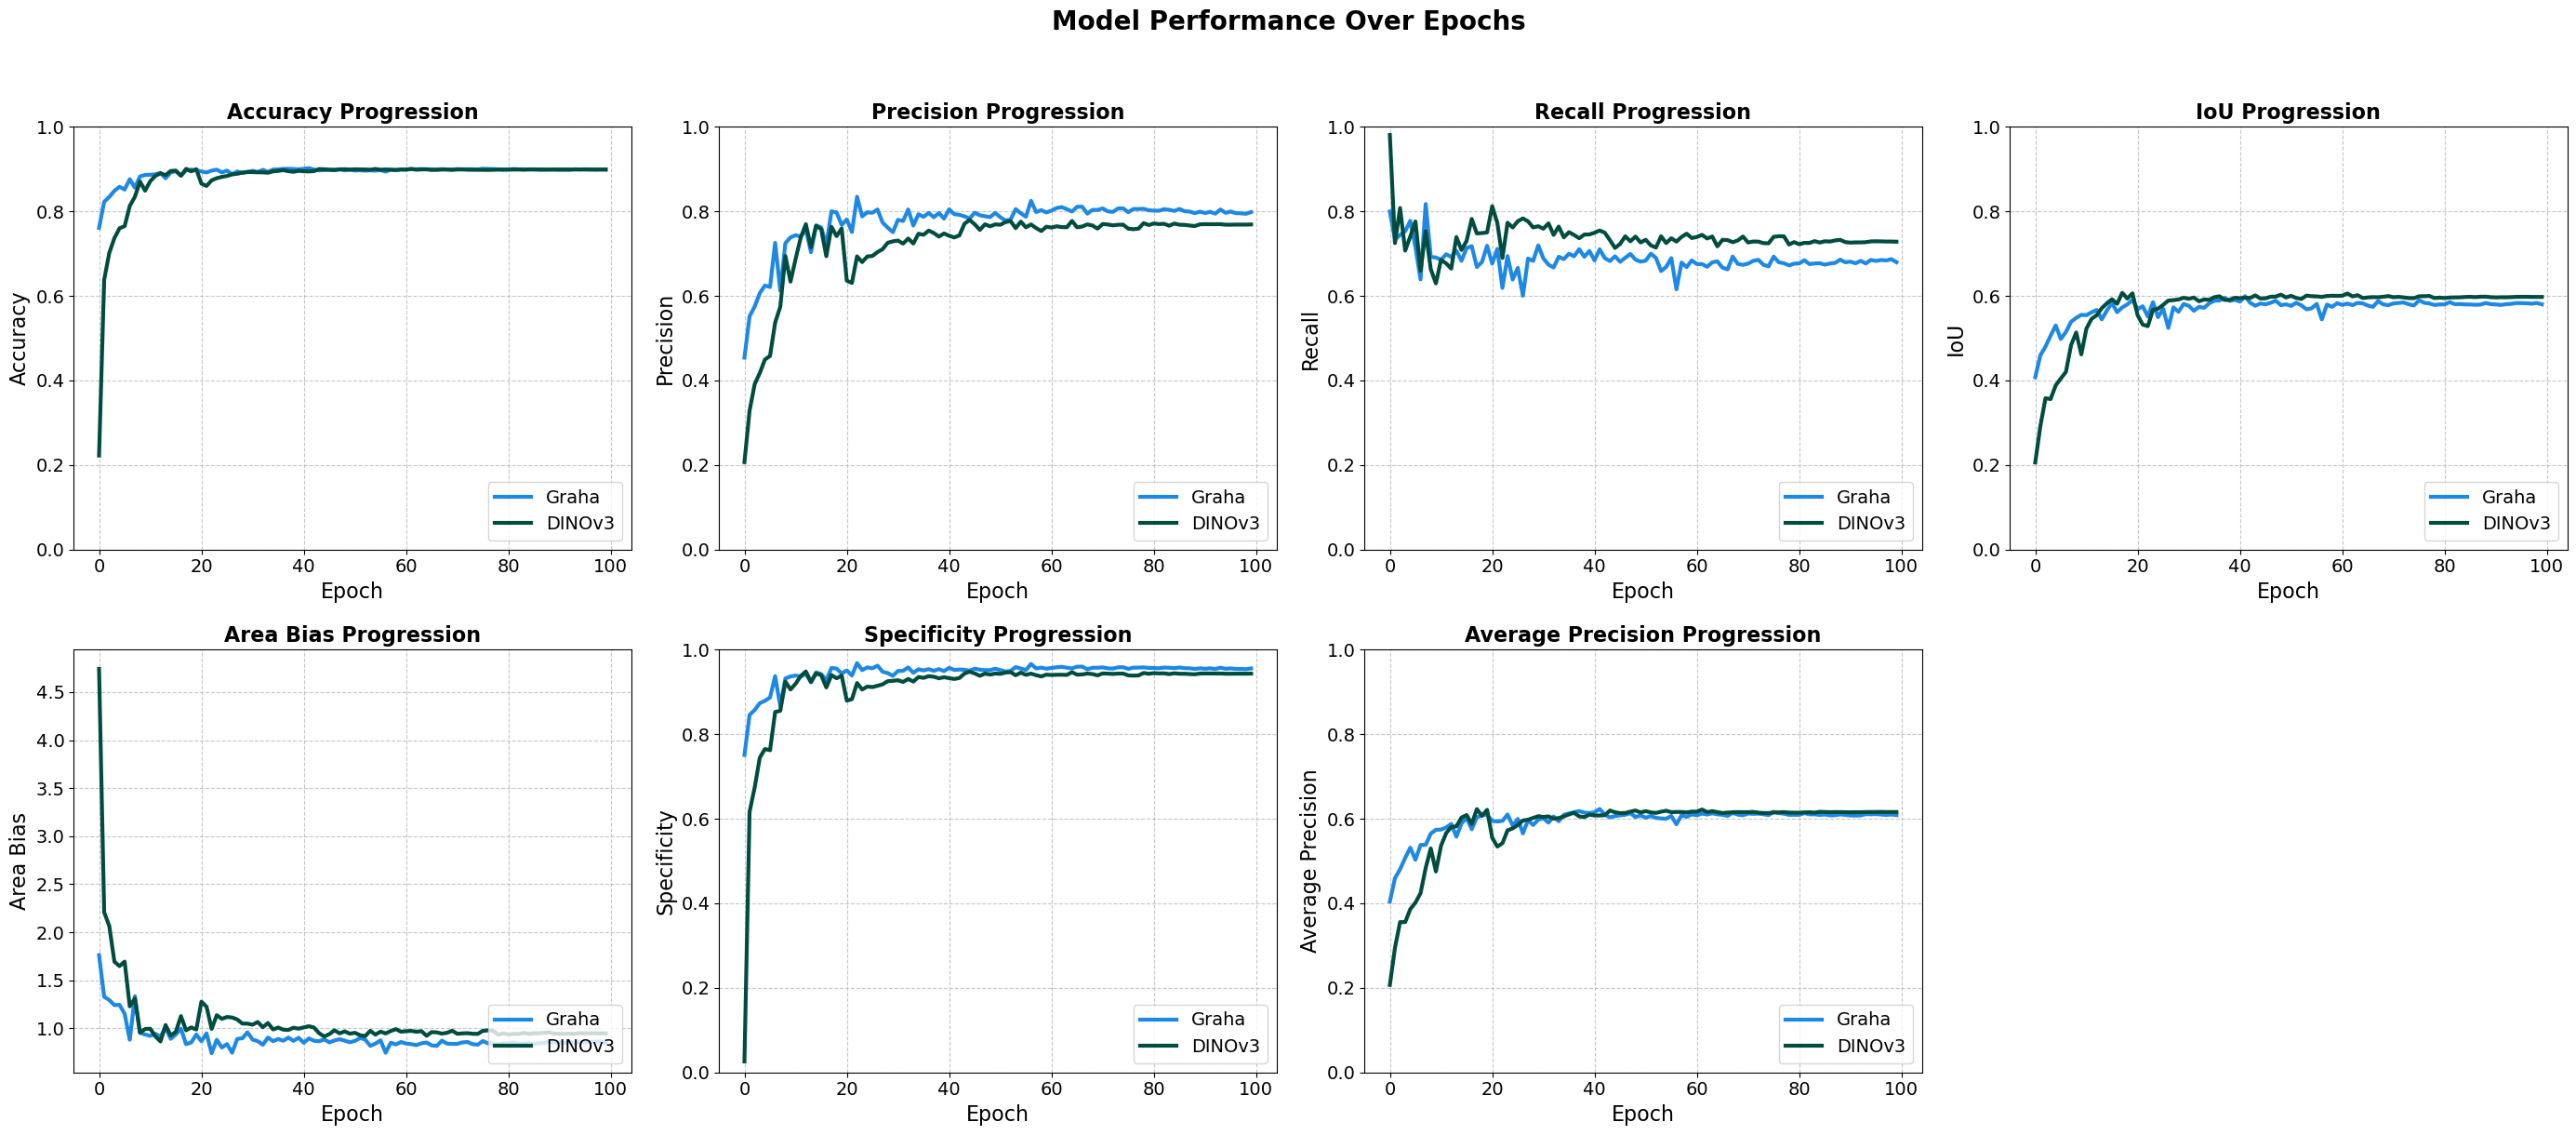

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
axes = axes.flatten()

for i, metric in enumerate(METRICS_TO_PLOT):
    ax = axes[i]

    if metric in df_graha.columns and not df_graha.empty:
        ax.plot(df_graha["Epoch"], df_graha[metric], label="Graha", color=COLOR_GRAHA, linewidth=3)

    if metric in df_dino.columns and not df_dino.empty:
        ax.plot(df_dino["Epoch"], df_dino[metric], label="DINOv3", color="#004D40", linewidth=3)

    ax.set_title(f"{metric} Progression", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    if metric != "Area Bias":
        ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend(loc="lower right")

axes[7].set_visible(False)

plt.suptitle("Model Performance Over Epochs", fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "metric_progression_by_epoch.png")
plt.show()